In [1]:
from pathlib import Path
import sys


SCENARIO_DIR = Path.cwd()
REPO_ROOT = SCENARIO_DIR.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline


SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}

max_routes = 1
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes)
)

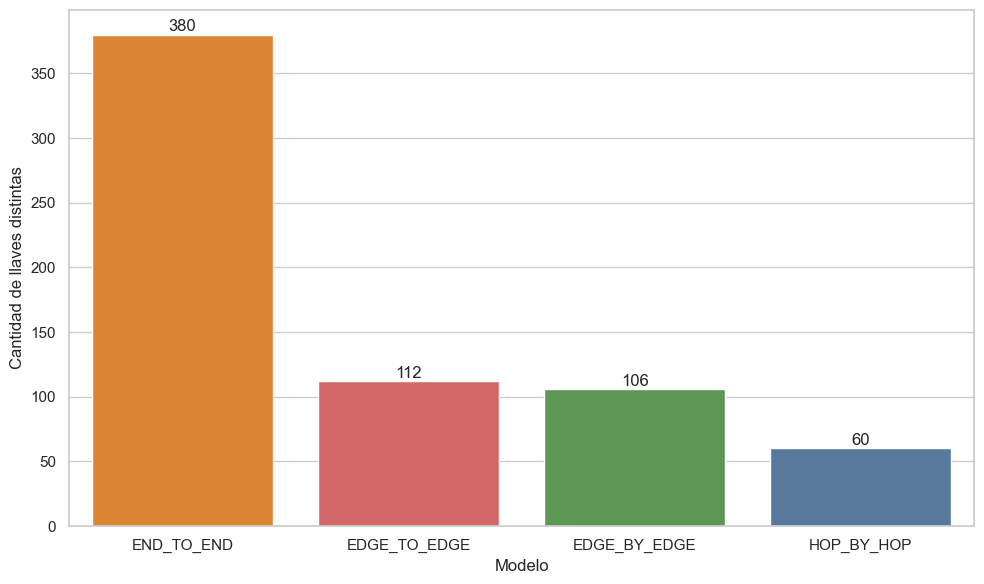

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
    "hbh": "#4c78a8",
    "e2e": "#f58518",
    "ebe": "#54a24b",
    "ete": "#e45756",
    "hop_by_hop": "#4c78a8",
    "end_to_end": "#f58518",
    "edge_by_edge": "#54a24b",
    "edge_to_edge": "#e45756",
}


def palette_for(values):
    unique_values = list(dict.fromkeys(values))
    return {value: MODEL_PALETTE.get(value, "#4c78a8") for value in unique_values}

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

planner = RouteActivationPlanner()

rows = []
for label, sim_result in [("Dirigidas", result)]:
    for model in SecurityModelType:
        rows.append(
            {
                "mode": label,
                "model": model.name,
                "unique_keys": len(planner.build_for_model(sim_result.security, model=model).key_scopes),
            }
        )

df = pd.DataFrame(rows)

pivot = df.pivot(index="model", columns="mode", values="unique_keys").reset_index()
pivot = pivot.sort_values("Dirigidas", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=pivot,
    x="model",
    y="Dirigidas",
    hue="model",
    dodge=False,
    palette=palette_for(pivot["model"]),
    legend=False,
)
ax.set_ylabel("Cantidad de llaves distintas")
ax.set_xlabel("Modelo")

for i, value in enumerate(pivot["Dirigidas"]):
    ax.text(i, value + 0.3, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


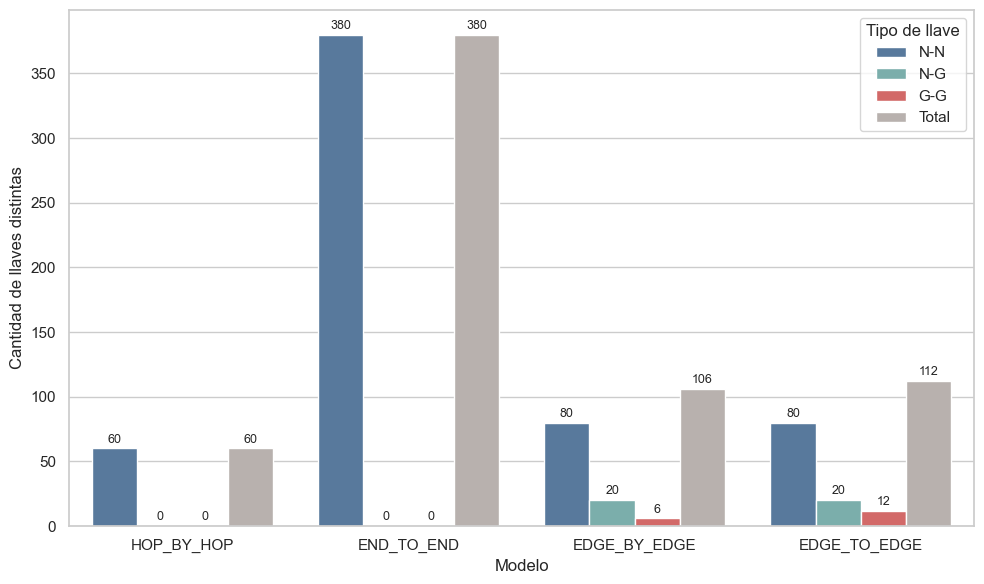

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from modules.security.models import SecurityModelType, KeyType
from pipelines.route_activation import RouteActivationPlanner

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
}

KEY_TYPE_ORDER = ["N-N", "N-G", "G-G", "Total"]

planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    key_scopes = planning.key_scopes

    counts = {
        "N-N": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_NODE),
        "N-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_GROUP),
        "G-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.GROUP_TO_GROUP),
    }
    counts["Total"] = len(key_scopes)

    for key_type_label in KEY_TYPE_ORDER:
        rows.append(
            {
                "model": model.name,
                "key_type": key_type_label,
                "count": counts[key_type_label],
            }
        )

df = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="model",
    y="count",
    hue="key_type",
    hue_order=KEY_TYPE_ORDER,
    palette=["#4c78a8", "#72b7b2", "#e45756", "#bab0ac"],
)

ax.set_ylabel("Cantidad de llaves distintas")
ax.set_xlabel("Modelo")
ax.legend(title="Tipo de llave")

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

from modules.security.models import SecurityModelType, KeyType

def unique_scopes_by_model(sim_result, model_type):
    return {
        req.scope
        for pair in sim_result.security.pairs
        for plan in sim_result.security.plans_by_model[model_type][pair]
        for req in plan.key_requirements
    }

def format_scope(scope):
    return f"G{scope.source_id}->G{scope.target_id}"

ebe_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_BY_EDGE)
ete_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_TO_EDGE)

ebe_gg = {
    scope for scope in ebe_scopes
    if scope.key_type == KeyType.GROUP_TO_GROUP
}
ete_gg = {
    scope for scope in ete_scopes
    if scope.key_type == KeyType.GROUP_TO_GROUP
}

summary_df = pd.DataFrame(
    [
        {"Modelo": "EdBEd", "G-G únicos": len(ebe_gg)},
        {"Modelo": "Ed2Ed", "G-G únicos": len(ete_gg)},
    ]
)

all_gg = sorted(
    ebe_gg | ete_gg,
    key=lambda scope: (scope.source_id, scope.target_id),
)

comparison_df = pd.DataFrame(
    {
        "Scope": [format_scope(scope) for scope in all_gg],
        "EdBEd": [format_scope(scope) if scope in ebe_gg else "" for scope in all_gg],
        "Ed2Ed": [format_scope(scope) if scope in ete_gg else "" for scope in all_gg],
    }
)

display(summary_df)
display(comparison_df)


,Modelo,G-G únicos
0,EdBEd,6
1,Ed2Ed,12


,Scope,EdBEd,Ed2Ed
0,G1->G2,G1->G2,G1->G2
1,G1->G3,,G1->G3
2,G1->G4,,G1->G4
3,G2->G1,G2->G1,G2->G1
4,G2->G3,G2->G3,G2->G3
5,G2->G4,,G2->G4
6,G3->G1,,G3->G1
7,G3->G2,G3->G2,G3->G2
8,G3->G4,G3->G4,G3->G4
9,G4->G1,,G4->G1


```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

```

```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

    G1 -.-> G3
    G1 -.-> G4
    G2 -.-> G4
    G3 -.-> G1
    G4 -.-> G1
    G4 -.-> G2

```

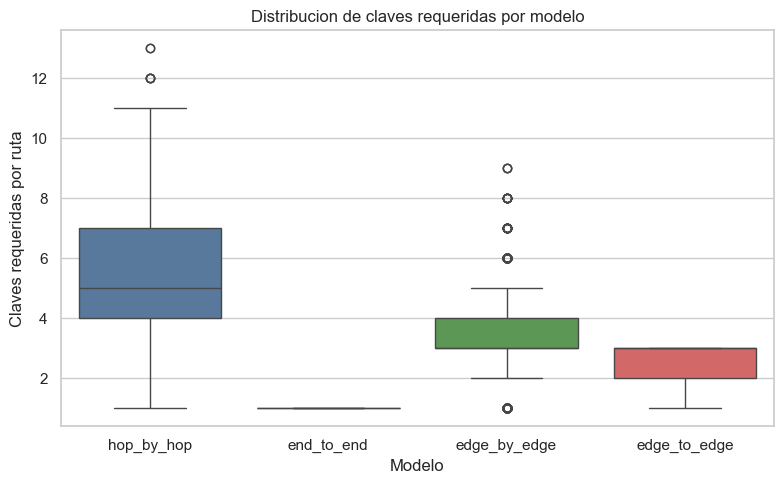

In [5]:
import pandas as pd

rows = []

for model, plans_by_pair in result.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        for plan in plans:
            unique_scopes = {req.scope for req in plan.key_requirements}
            rows.append(
                {
                    "model": model.name.lower(),
                    "pair": f"{pair[0]}->{pair[1]}",
                    "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                    "required_keys": len(unique_scopes),
                }
            )

df_keys = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))
sns.boxenplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    dodge=False,
    palette=palette_for(df_keys["model"]),
    legend=False,
)
plt.title("Distribucion de claves requeridas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Claves requeridas por ruta")
plt.tight_layout()
plt.show()


## Maximizar rutas sujeto a presupuesto de llaves

:::: {layout="[0.5, 0.5]"}

:::{#firstcol}
\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
B &: \text{presupuesto máximo de llaves activas} \\
\end{aligned}
:::

:::{#secondcol}
\begin{aligned}
\max \quad & \sum_{r \in R} x_r \\
\text{s.a.} \quad
& \sum_{k \in K} y_k \le B \\
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
:::


::::


In [9]:
import pandas as pd

df_m1 = pd.DataFrame()
for sec_model in SERIES_COLORS.keys():
    from models.model1_max_routes import solve_for_security_model
    
    df_m1 = pd.concat([df_m1,solve_for_security_model(result, sec_model)])

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar


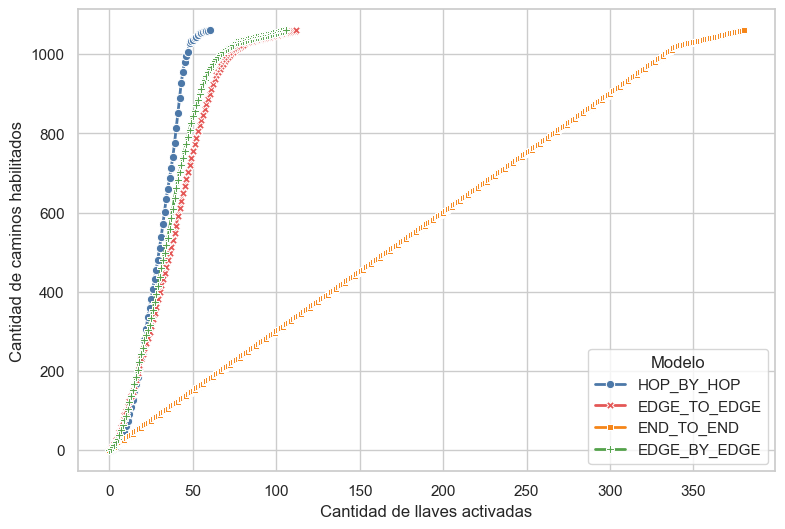

In [10]:
#| echo: false
plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=df_m1.sort_values("selected_keys"),
    x="selected_keys",
    y="selected_routes",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    palette=palette_for(df_m1["model"]),
)
ax.set_xlabel("Cantidad de llaves activadas")
ax.set_ylabel("Cantidad de caminos habilitados")
ax.legend(title="Modelo")
plt.show()

#Normalizarlo y mostrar en porcentajes capaz, respecto del total de caminos y del total de llaves


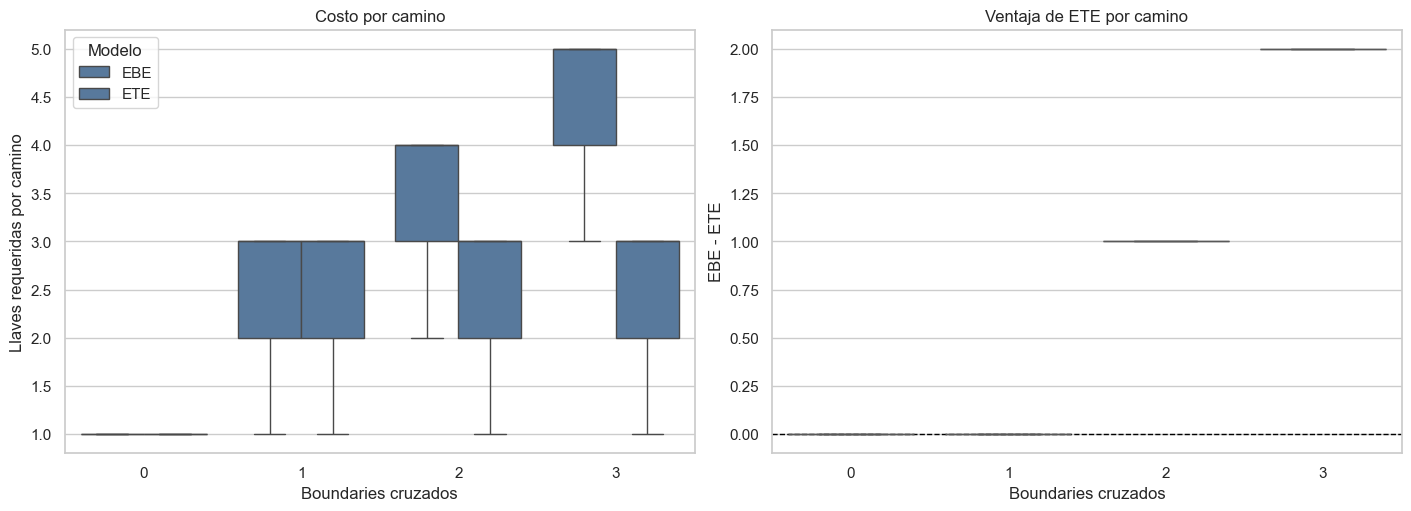

Chequeo: cantidad de caminos donde ETE usa mas llaves que EBE: 0


In [9]:
import pandas as pd
from modules.security.models import SecurityModelType

rows = []

for pair in result.routing.pairs:
    route = result.annotation.annotated_routes_by_pair[pair][0]
    boundaries_crossed = len(route.boundary_crossings)

    ebe_plan = result.security.plans_by_model[SecurityModelType.EDGE_BY_EDGE][pair][0]
    ete_plan = result.security.plans_by_model[SecurityModelType.EDGE_TO_EDGE][pair][0]

    ebe_keys = len({req.scope for req in ebe_plan.key_requirements})
    ete_keys = len({req.scope for req in ete_plan.key_requirements})

    rows.append({
        "pair": f"{pair[0]}->{pair[1]}",
        "boundaries_crossed": boundaries_crossed,
        "EBE": ebe_keys,
        "ETE": ete_keys,
        "delta_ebe_minus_ete": ebe_keys - ete_keys,
    })

df_paths = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

plot_df = df_paths.melt(
    id_vars=["pair", "boundaries_crossed"],
    value_vars=["EBE", "ETE"],
    var_name="model",
    value_name="required_keys",
)

sns.boxplot(
    data=plot_df,
    x="boundaries_crossed",
    y="required_keys",
    hue="model",
    palette=palette_for(plot_df["model"]),
    ax=axes[0],
)
axes[0].set_xlabel("Boundaries cruzados")
axes[0].set_ylabel("Llaves requeridas por camino")
axes[0].set_title("Costo por camino")
axes[0].legend(title="Modelo")

sns.boxplot(
    data=df_paths,
    x="boundaries_crossed",
    y="delta_ebe_minus_ete",
    color="#72b7b2",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Boundaries cruzados")
axes[1].set_ylabel("EBE - ETE")
axes[1].set_title("Ventaja de ETE por camino")

plt.show()

print("Chequeo: cantidad de caminos donde ETE usa mas llaves que EBE:",
      (df_paths["delta_ebe_minus_ete"] < 0).sum())


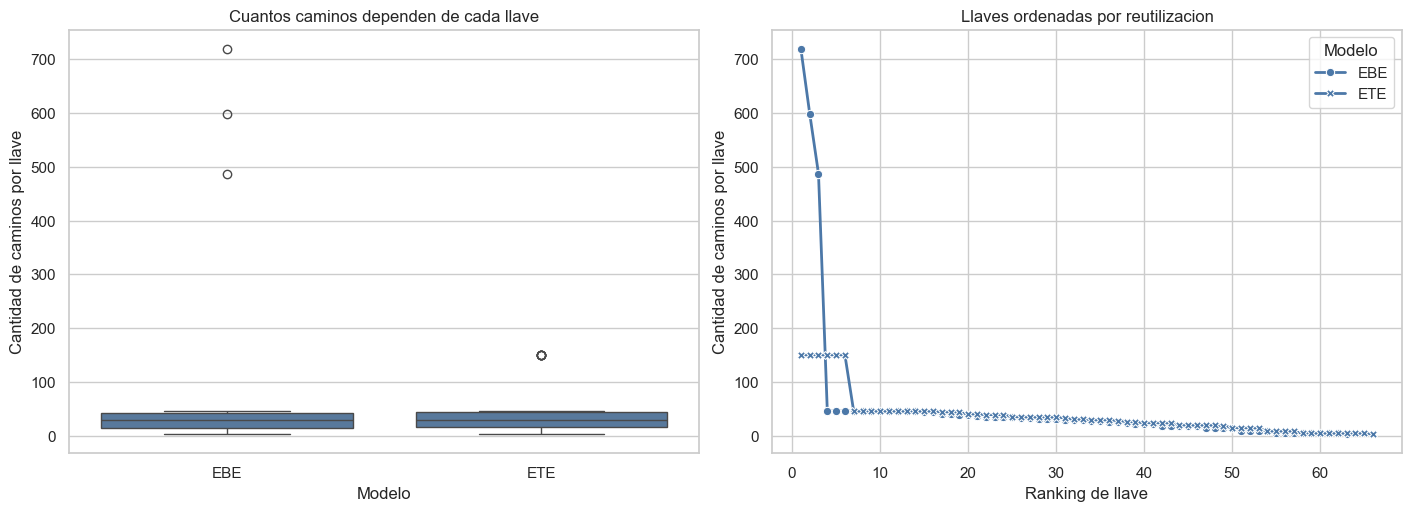

,mean,median,max
model,,,
EBE,53.555556,29.0,719.0
ETE,37.530303,29.5,150.0


In [10]:
import pandas as pd

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

rows = []

for sec_model, label in [
    (SecurityModelType.EDGE_BY_EDGE, "EBE"),
    (SecurityModelType.EDGE_TO_EDGE, "ETE"),
]:
    planning = RouteActivationPlanner().build_for_model(result.security, model=sec_model)

    routes_per_key = {scope: 0 for scope in planning.key_scopes}
    for req in planning.route_requirements:
        for scope in req.required_key_scopes:
            routes_per_key[scope] += 1

    for scope, coverage in routes_per_key.items():
        rows.append({
            "model": label,
            "scope": str(scope),
            "routes_covered": coverage,
        })

df_key_coverage = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.boxplot(
    data=df_key_coverage,
    x="model",
    y="routes_covered",
    hue="model",
    dodge=False,
    palette=palette_for(df_key_coverage["model"]),
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cuantos caminos dependen de cada llave")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("Cantidad de caminos por llave")

sns.lineplot(
    data=(
        df_key_coverage.sort_values(["model", "routes_covered"], ascending=[True, False])
        .assign(rank=lambda frame: frame.groupby("model").cumcount() + 1)
    ),
    x="rank",
    y="routes_covered",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    palette=palette_for(df_key_coverage["model"]),
    ax=axes[1],
)
axes[1].set_title("Llaves ordenadas por reutilizacion")
axes[1].set_xlabel("Ranking de llave")
axes[1].set_ylabel("Cantidad de caminos por llave")
axes[1].legend(title="Modelo")

plt.show()

display(
    df_key_coverage.groupby("model")["routes_covered"]
    .describe()[["mean", "50%", "max"]]
    .rename(columns={"50%": "median"})
)


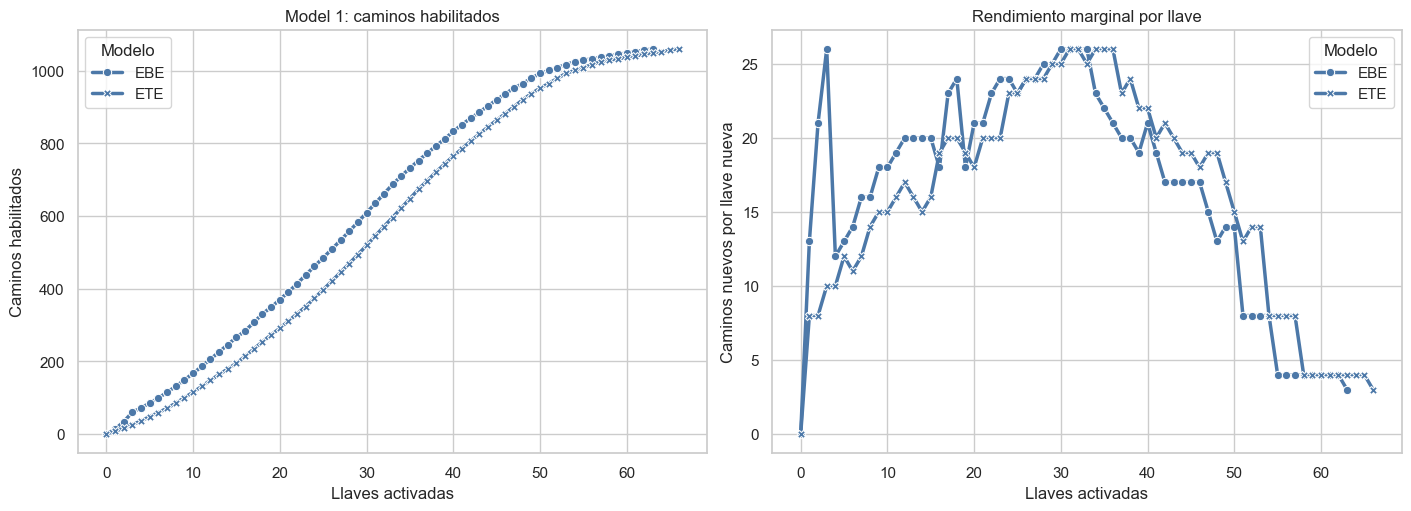

In [11]:
import pandas as pd

plot_models = ["EDGE_BY_EDGE", "EDGE_TO_EDGE"]
plot_labels = {"EDGE_BY_EDGE": "EBE", "EDGE_TO_EDGE": "ETE"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

plot_df = df_m1[df_m1["model"].isin(plot_models)].sort_values("selected_keys").copy()
plot_df["model_label"] = plot_df["model"].map(plot_labels)
plot_df["delta_routes"] = plot_df.groupby("model")["selected_routes"].diff().fillna(plot_df["selected_routes"])
plot_df["delta_keys"] = plot_df.groupby("model")["selected_keys"].diff().fillna(plot_df["selected_keys"].replace(0, 1))
plot_df["routes_per_new_key"] = plot_df["delta_routes"] / plot_df["delta_keys"].replace(0, 1)

sns.lineplot(
    data=plot_df,
    x="selected_keys",
    y="selected_routes",
    hue="model_label",
    style="model_label",
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette=palette_for(plot_df["model_label"]),
    ax=axes[0],
)
axes[0].set_title("Model 1: caminos habilitados")
axes[0].set_xlabel("Llaves activadas")
axes[0].set_ylabel("Caminos habilitados")
axes[0].legend(title="Modelo")

sns.lineplot(
    data=plot_df,
    x="selected_keys",
    y="routes_per_new_key",
    hue="model_label",
    style="model_label",
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette=palette_for(plot_df["model_label"]),
    ax=axes[1],
)
axes[1].set_title("Rendimiento marginal por llave")
axes[1].set_xlabel("Llaves activadas")
axes[1].set_ylabel("Caminos nuevos por llave nueva")
axes[1].legend(title="Modelo")

plt.show()


## Minimizar llaves para un porcentaje de conectividad entre pares


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\alpha &: \text{fracción o porcentaje objetivo de conectividad}
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
$$
z_p =
\begin{cases}
1 & \text{si el par } p \text{ tiene al menos 1 ruta } \\
0 & \text{en otro caso}
\end{cases}
$$

:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \le z_p \qquad \forall p \in P,\ \forall r \in R_p \\
& z_p \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& \sum_{p \in P} z_p \ge \left\lceil \alpha |P| \right\rceil \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
& z_p \in \{0,1\} \qquad \forall p \in P
\end{aligned}

:::


::::


In [12]:
import pandas as pd


df_m2 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model2_min_keys import solve_for_security_model
    
    df_m2 = pd.concat([df_m2, solve_for_security_model(result,sec_model)], ignore_index=True)

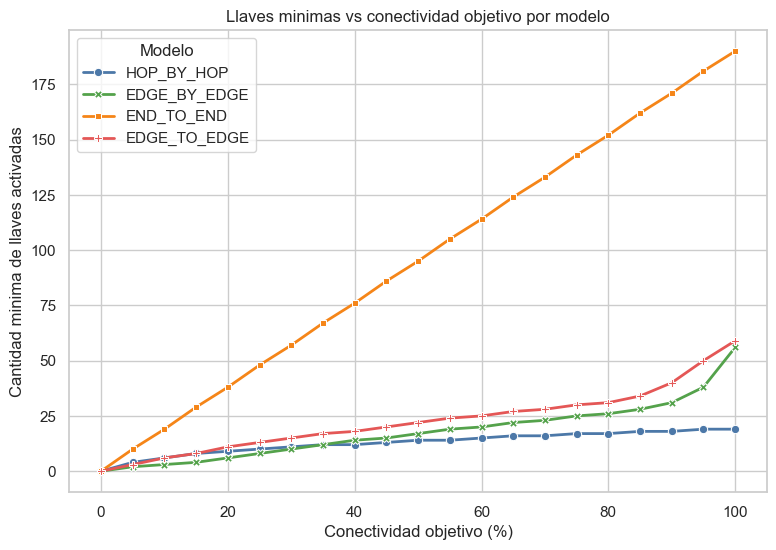

In [13]:
#| echo: false
plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=df_m2.sort_values("target_connectivity_pct"),
    x="target_connectivity_pct",
    y="selected_keys",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    palette=palette_for(df_m2["model"]),
)
ax.set_xlabel("Conectividad objetivo (%)")
ax.set_ylabel("Cantidad minima de llaves activadas")
ax.set_title("Llaves minimas vs conectividad objetivo por modelo")
ax.legend(title="Modelo")
plt.show()


## Minimizar llaves garantizando al menos 1 camino por par


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& 1 \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
\end{aligned}

:::


::::


In [14]:
import pandas as pd


df_m3 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model3_min_keys_full_connectivity import solve_for_security_model
    
    df_m3 = pd.concat([df_m3, solve_for_security_model(result,sec_model)], ignore_index=True)

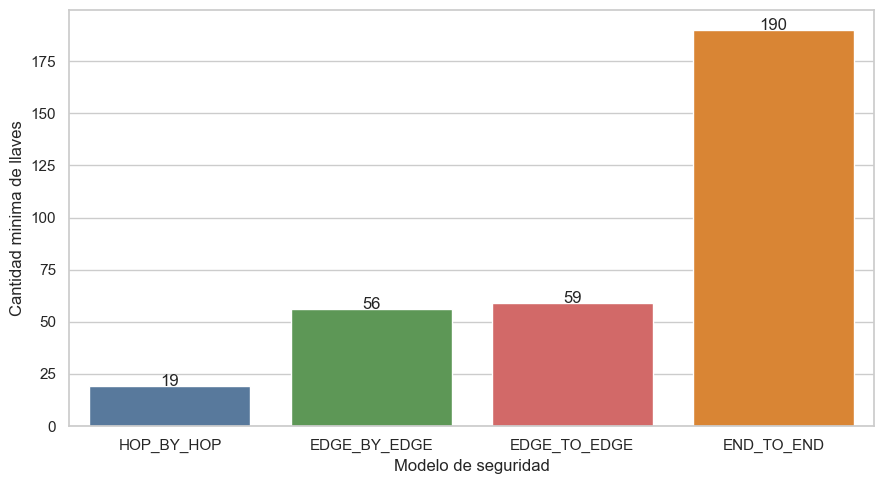

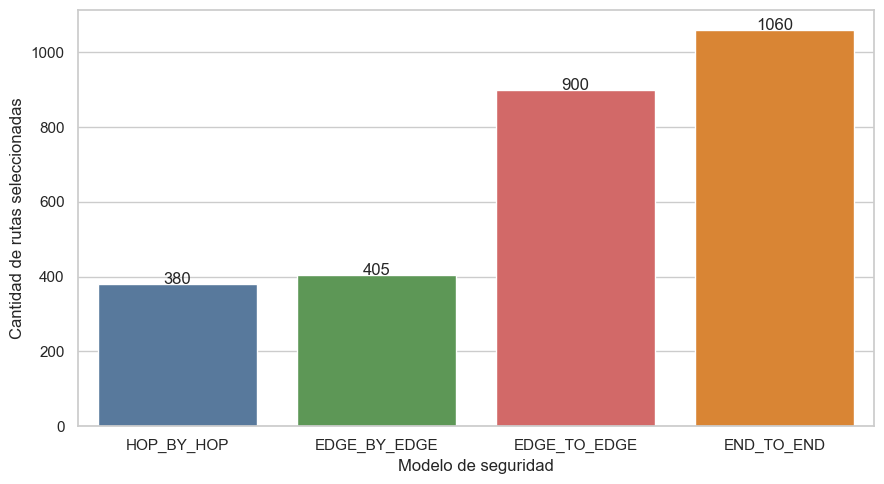

In [15]:
#| label: fig-gapminder
#| fig-cap: "Resultados de modelo 3"
#| fig-subcap:
#|   - "Llaves minimas para garantizar al menos 1 camino por par"
#|   - "Rutas seleccionadas en la solucion optima"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

plot_df = df_m3.sort_values("selected_keys").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_keys",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad minima de llaves")

for i, value in enumerate(plot_df["selected_keys"]):
    ax.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

plot_df = df_m3.sort_values("selected_routes").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_routes",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad de rutas seleccionadas")

for i, value in enumerate(plot_df["selected_routes"]):
    ax.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()
